- [Steps]()
    - [Sine]()
- [Sine]()
    - [Steps]()

In [1]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from scipy.interpolate import interp1d

In [2]:
filename = [os.path.join(dir, "data", "step_tests.csv"), 
            os.path.join(dir, "data", "tclab_sine_test.csv")]

steps = pd.read_csv(filename[0])
sine = pd.read_csv(filename[1])

# Known parameters:
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units

In [3]:
def parse(data):
    """'data' is a pd.DataFrame. Returned is 'tvec', 'Ts1', 'u1'."""
    Tamb = data["T1"][0]
    return data["Time"].values, data["T1"].values - Tamb, data["Q1"].values, Tamb


def params(tvec, Ts1, u1, param0=None):
    """Optimize parameters for mechanistic model. Returned is 'Ua', 'Ub', 'CpH', 'CpS'."""
    if param0 is None:  # initial point
        param0 = [0.05,  # Ua, watts/deg C
                 0.05,  # Ub, watts/deg C
                 5,     # CpH, joules/deg C
                 1]     # CpS, joules/deg C

    # Solve model:

    u1_interp = interp1d(tvec, u1, kind='previous')

    def tclab_model(param):
        Ua, Ub, CpH, CpS = param  # adjustable parameters

        def deriv(t, y):  # two-state model
            T1H, T1S = y
            dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) / CpH
            dT1S = Ub * (T1H - T1S) / CpS
            return [dT1H, dT1S]
        
        soln = solve_ivp(deriv, [tvec[0], tvec[-1]], [0, 0], t_eval=tvec)  # model solution
        
        pred = pd.DataFrame()  # dataframe with predictions
        pred["Time"] = tvec
        pred["TH1"] = soln.y[0]
        pred["TS1"] = soln.y[1]
        pred["Q1"] = u1_interp(tvec)

        return pred

    # Regress model
    def residuals(param):
        pred = tclab_model(param)
        return pred["TS1"] - Ts1
    
    # Set bounds (non-negative):
    bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

    # Perform least squares nonlinear regression:
    nl_results = least_squares(residuals, param0, bounds=bnds, method='trf', verbose=2, loss="arctan")

    param = nl_results.x
    return param, tclab_model(param)["TS1"].values, tclab_model(param)["TH1"].values  # == [Ua, Ub, CpH, CpS], Ts1_prediction, Th1_prediction


def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

In [87]:
def r(t):  # setpoint/reference
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb, Tamb, 60, 60, 35] - Tamb)
    # return np.interp(t, tvec, Ts1)

# BENCHMARK

In [103]:
# Cycle through 'steps' and 'sine' datasets:
for data in [steps]:  # , sine]:
    
    # Parse dataset:
    tvec, Ts1, u1, _ = parse(data)

    # Optimize two-state model parameters:
    param, _, _ = params(tvec, Ts1, u1)

    # Create Pyomo model:

    Ua, Ub, CpH, CpS = param

    m = pyo.ConcreteModel("TCLab")
    m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))
    
    m.Th1 = pyo.Var(m.t)
    m.Ts1 = pyo.Var(m.t)
    m.u1 = pyo.Var(m.t, bounds=(0, 100))

    m.dTh1 = dae.DerivativeVar(m.Th1)
    m.dTs1 = dae.DerivativeVar(m.Ts1)

    m.Th1[0].fix(0.0)  # initial conditions
    m.Ts1[0].fix(0.0)

    @m.Constraint(m.t)  # first differential equation
    def heater1(m, t):
        return (
            CpH * m.dTh1[t]
            == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
        )

    @m.Constraint(m.t)  # second differential equation
    def sensor1(m, t):
        return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])
    
    @m.Integral(m.t)  # integral of squared error
    def ise(m, t):
        return (r(t) - m.Ts1[t]) ** 2

    @m.Objective(sense=pyo.minimize)  # objective function
    def objective(m):
        return m.ise

    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
    pyo.SolverFactory('ipopt').solve(m, tee=True)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.5405e+02                                    6.97e+04    
       1              6         4.3414e+02      1.20e+02       9.07e-03       2.30e+04    
       2              7         3.6673e+02      6.74e+01       3.80e-02       6.91e+03    
       3              8         3.2434e+02      4.24e+01       3.99e-02       1.07e+04    
       4              9         2.8035e+02      4.40e+01       8.08e-02       6.86e+03    
       5             10         2.5676e+02      2.36e+01       1.59e-01       2.40e+03    
       6             11         1.4862e+02      1.08e+02       1.59e-01       2.52e+03    
       7             12         1.3887e+02      9.75e+00       2.17e-01       1.48e+03    
       8             18         1.3714e+02      1.73e+00       8.14e-05       1.08e+03    
       9             20         1.3651e+02      6.38e-01       3.65e-05       2.38e+03    

In [104]:
sol_t = m.t
sol_b = m.Ts1[:]()
sol_u_b = m.u1[:]()

# BLACK BOX

In [121]:
filename = "v13.2_steps__black_box.fokl"

# Cycle through 'steps' and 'sine' datasets:
for data in [steps]:  # , sine]:

    # Parse dataset:
    tvec, Ts1, u1, Tamb = parse(data)
    n = len(tvec)
    dt = (tvec[-1] - tvec[0]) / (n - 1)
    
    # Derivative of smoothed data:
    dTs1 = gradient_h4(smooth(Ts1, 9), dt)

    # Train GP on two-state model predictions (i.e., un-corrected Th1, Ts1) and measured u1:
    pathname = os.path.join(dir, "models", filename)
    try:
        GP = FoKLRoutines.load(pathname)
    except Exception as exception:
        GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
        GP.fit([Ts1, u1], dTs1, clean=True, pillow=[[0.01, 0.05], [0, 0]])
        GP.save(pathname)

    # Create Pyomo model:

    m = pyo.ConcreteModel("TCLab")
    m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))
    
    m.Ts1 = pyo.Var(m.t, bounds=GP.minmax[0])
    m.u1 = pyo.Var(m.t, bounds=GP.minmax[1])
    m.dTs1 = dae.DerivativeVar(m.Ts1)

    m.Ts1[0].fix(0.0)  # initial conditions

    fokl_to_pyomo(GP, [m.Ts1, m.u1], m.dTs1, m, m.t)
    
    @m.Integral(m.t)  # integral of squared error
    def ise(m, t):
        return (r(t) - m.Ts1[t]) ** 2

    @m.Objective(sense=pyo.minimize)  # objective function
    def objective(m):
        return m.ise

    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
    pyo.SolverFactory('ipopt').solve(m, tee=True)

[1, -4658.566290504541]
[2, -4658.566290504541]
[2, -4665.571499785414]
[3, -4709.301454342197]
[3, -4747.567587212715]
[4, -4748.374362926943]
[4, -4807.630303372217]
[4, -5047.575234647359]
[5, -5103.18859274555]
[5, -5109.4261231225655]
[5, -5219.888039723934]
[6, -5301.131752736828]
[6, -5414.269323059883]
[6, -5421.179884523162]
[6, -5423.035112440665]
[7, -5426.655482340465]
[7, -5428.668409377785]
[7, -5495.383465941183]
[7, -5536.964977700491]
[8, -5537.860702503389]
[8, -5551.474000835059]
[8, -5565.99239852404]
[8, -5564.152285645637]
[8, -5561.635050176337]
[9, -5560.019072685137]
Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://

In [123]:
sol_blackBox = m.Ts1[:]()
sol_u_blackBox = m.u1[:]()

# Derivative of Residual

In [110]:
filename = ["v13.2_steps.fokl", "v13.2_sine.fokl"]

# Cycle through 'steps' and 'sine' datasets:
i = -1
for data in [steps]:  # , sine]:
    i += 1
    
    # Parse dataset:
    tvec, Ts1, u1, Tamb = parse(data)
    n = len(tvec)
    dt = (tvec[-1] - tvec[0]) / (n - 1)
    
    # Optimize two-state model parameters:
    param, Ts1_p, Th1_p = params(tvec, Ts1, u1)

    # Derivative of smoothed data:
    dTs1 = gradient_h4(smooth(Ts1, 9), dt)
    dTs1_p = gradient_h4(Ts1_p, dt)  # Ts1_p already smooth
    
    # Residual of derivative:
    dR = dTs1 - dTs1_p

    # Train GP on two-state model predictions (i.e., un-corrected Th1, Ts1) and measured u1:
    pathname = os.path.join(dir, "models", filename[i])
    try:
        GP = FoKLRoutines.load(pathname)
    except Exception as exception:
        GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
        GP.fit([Th1_p, Ts1_p, u1], dR, clean=True, pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]])
        GP.save(pathname)

    # Create Pyomo model:

    Ua, Ub, CpH, CpS = param

    m = pyo.ConcreteModel("TCLab")
    m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))
    
    m.Th1 = pyo.Var(m.t, bounds=GP.minmax[0])  # un-corrected
    m.Ts1 = pyo.Var(m.t, bounds=GP.minmax[1])  # un-corrected
    m.u1 = pyo.Var(m.t, bounds=GP.minmax[2])
    m.Th1_R = pyo.Var(m.t)  # Th1 integrated with residual
    m.Ts1_R = pyo.Var(m.t)  # Ts1 integrated with residual
    m.R = pyo.Var(m.t)  # residual
    
    m.dTh1 = dae.DerivativeVar(m.Th1)
    m.dTs1 = dae.DerivativeVar(m.Ts1)
    m.dTh1_R = dae.DerivativeVar(m.Th1_R)
    m.dTs1_R = dae.DerivativeVar(m.Ts1_R)
    m.dR = dae.DerivativeVar(m.R)

    m.Th1[0].fix(0.0)  # initial conditions
    m.Ts1[0].fix(0.0)
    m.Th1_R[0].fix(0.0)
    m.Ts1_R[0].fix(0.0)
    m.R[0].fix(0.0)

    fokl_to_pyomo(GP, [m.Th1, m.Ts1, m.u1], m.dR, m, m.t)

    @m.Constraint(m.t)  # first differential equation
    def heater1(m, t):
        return (
            CpH * m.dTh1[t]
            == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
        )

    @m.Constraint(m.t)  # second differential equation
    def sensor1(m, t):
        return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])
    
    @m.Constraint(m.t)  # second differential equation, with residual
    def sensor1_residual(m, t):
        return m.dTs1_R[t] == m.dTs1[t] + m.dR[t]
    
    # @m.Constraint(m.t)  # first differential equation, with residual
    # def heater1_residual(m, t):
    #     return (
    #         CpH * m.dTh1_R[t]
    #         == -Ua * m.Th1_R[t] + Ub * (m.Ts1_R[t] - m.Th1_R[t]) + alpha * P1 * m.u1[t]
    #     )

    @m.Integral(m.t)  # integral of squared error
    def ise(m, t):
        return (r(t) - m.Ts1_R[t]) ** 2

    @m.Objective(sense=pyo.minimize)  # objective function
    def objective(m):
        return m.ise

    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
    # pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=200, wrt=m.t)
    pyo.SolverFactory('ipopt').solve(m, tee=True)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.5405e+02                                    6.97e+04    
       1              6         4.3414e+02      1.20e+02       9.07e-03       2.30e+04    
       2              7         3.6673e+02      6.74e+01       3.80e-02       6.91e+03    
       3              8         3.2434e+02      4.24e+01       3.99e-02       1.07e+04    
       4              9         2.8035e+02      4.40e+01       8.08e-02       6.86e+03    
       5             10         2.5676e+02      2.36e+01       1.59e-01       2.40e+03    
       6             11         1.4862e+02      1.08e+02       1.59e-01       2.52e+03    
       7             12         1.3887e+02      9.75e+00       2.17e-01       1.48e+03    
       8             18         1.3714e+02      1.73e+00       8.14e-05       1.08e+03    
       9             20         1.3651e+02      6.38e-01       3.65e-05       2.38e+03    

In [111]:
sol_dR = m.Ts1_R[:]()
sol_R_via_dR = m.R[:]()
sol_u_dR = m.u1[:]()

# Residual

In [107]:
filename = ["v13.2_steps__resid.fokl", "v13.2_sine__resid.fokl"]

# Cycle through 'steps' and 'sine' datasets:
i = -1
for data in [steps]:  # , sine]:
    i += 1
    
    # Parse dataset:
    tvec, Ts1, u1, Tamb = parse(data)
    n = len(tvec)
    dt = (tvec[-1] - tvec[0]) / (n - 1)
    
    # Optimize two-state model parameters:
    param, Ts1_p, Th1_p = params(tvec, Ts1, u1)

    # Derivative of smoothed data:
    dTs1 = gradient_h4(smooth(Ts1, 9), dt)
    dTs1_p = gradient_h4(Ts1_p, dt)  # Ts1_p already smooth
    
    # Residual of derivative:
    # dR = dTs1 - dTs1_p
    R = Ts1 - Ts1_p

    # Train GP on two-state model predictions (i.e., un-corrected Th1, Ts1) and measured u1:
    pathname = os.path.join(dir, "models", filename[i])
    try:
        GP = FoKLRoutines.load(pathname)
    except Exception as exception:
        GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
        GP.fit([Th1_p, Ts1_p, u1], R, clean=True, pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]])
        GP.save(pathname)

    # Create Pyomo model:

    Ua, Ub, CpH, CpS = param

    m = pyo.ConcreteModel("TCLab")
    m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))
    
    m.Th1 = pyo.Var(m.t, bounds=GP.minmax[0])  # un-corrected
    m.Ts1 = pyo.Var(m.t, bounds=GP.minmax[1])  # un-corrected
    m.u1 = pyo.Var(m.t, bounds=GP.minmax[2])
    # m.Th1_R = pyo.Var(m.t)  # Th1 integrated with residual
    m.Ts1_R = pyo.Var(m.t)  # Ts1 integrated with residual
    m.R = pyo.Var(m.t)  # residual
    
    m.dTh1 = dae.DerivativeVar(m.Th1)
    m.dTs1 = dae.DerivativeVar(m.Ts1)
    # m.dTh1_R = dae.DerivativeVar(m.Th1_R)
    # m.dTs1_R = dae.DerivativeVar(m.Ts1_R)
    # m.dR = dae.DerivativeVar(m.R)

    m.Th1[0].fix(0.0)  # initial conditions
    m.Ts1[0].fix(0.0)
    # m.Th1_R[0].fix(0.0)
    m.Ts1_R[0].fix(0.0)
    m.R[0].fix(0.0)

    fokl_to_pyomo(GP, [m.Th1, m.Ts1, m.u1], m.R, m, m.t)

    @m.Constraint(m.t)  # first differential equation
    def heater1(m, t):
        return (
            CpH * m.dTh1[t]
            == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
        )

    @m.Constraint(m.t)  # second differential equation
    def sensor1(m, t):
        return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])
    
    @m.Constraint(m.t)  # second differential equation, with residual
    def sensor1_residual(m, t):
        return m.Ts1_R[t] == m.Ts1[t] + m.R[t]
    
    # @m.Constraint(m.t)  # first differential equation, with residual
    # def heater1_residual(m, t):
    #     return (
    #         CpH * m.dTh1_R[t]
    #         == -Ua * m.Th1_R[t] + Ub * (m.Ts1_R[t] - m.Th1_R[t]) + alpha * P1 * m.u1[t]
    #     )

    @m.Integral(m.t)  # integral of squared error
    def ise(m, t):
        # return (r(t) - m.Th1[t]) ** 2
        return (r(t) - m.Ts1_R[t]) ** 2

    @m.Objective(sense=pyo.minimize)  # objective function
    def objective(m):
        return m.ise

    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
    # pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=200, wrt=m.t)
    pyo.SolverFactory('ipopt').solve(m, tee=True)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.5405e+02                                    6.97e+04    
       1              6         4.3414e+02      1.20e+02       9.07e-03       2.30e+04    
       2              7         3.6673e+02      6.74e+01       3.80e-02       6.91e+03    
       3              8         3.2434e+02      4.24e+01       3.99e-02       1.07e+04    
       4              9         2.8035e+02      4.40e+01       8.08e-02       6.86e+03    
       5             10         2.5676e+02      2.36e+01       1.59e-01       2.40e+03    
       6             11         1.4862e+02      1.08e+02       1.59e-01       2.52e+03    
       7             12         1.3887e+02      9.75e+00       2.17e-01       1.48e+03    
       8             18         1.3714e+02      1.73e+00       8.14e-05       1.08e+03    
       9             20         1.3651e+02      6.38e-01       3.65e-05       2.38e+03    

In [108]:
sol_R = m.Ts1_R[:]()
sol_R_via_R = m.R[:]()
sol_u_R = m.u1[:]()

# COMPARISON

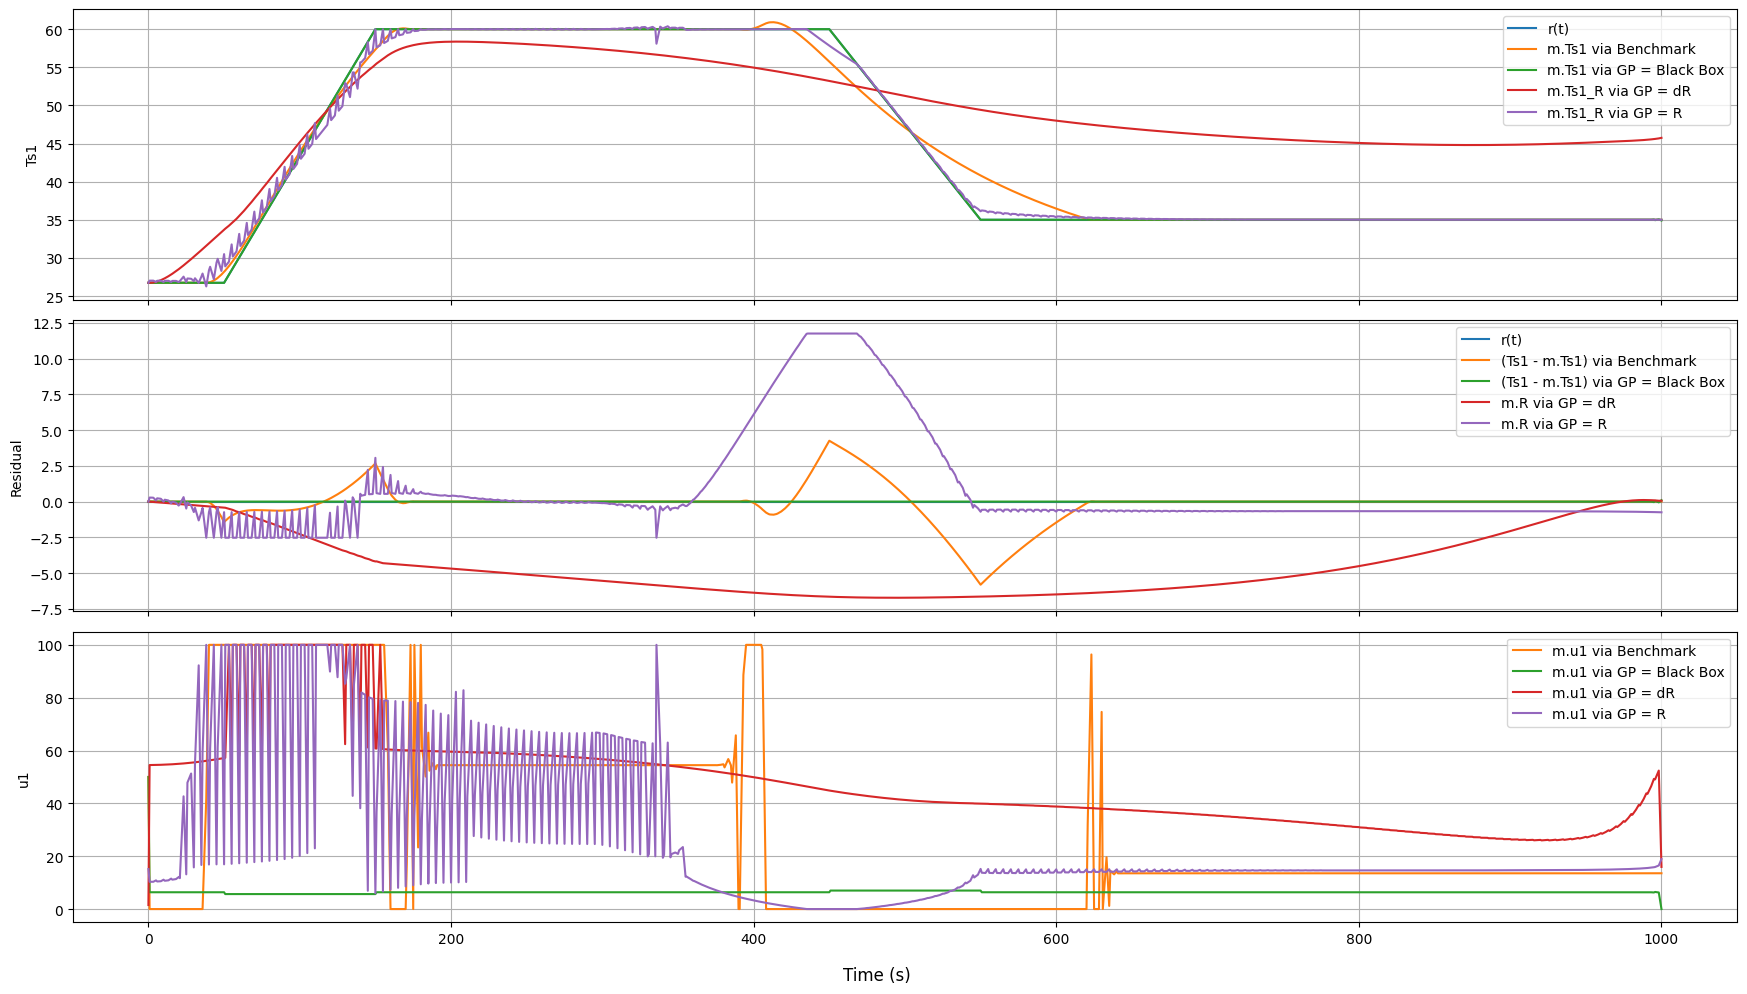

In [128]:
fig, ax = plt.subplots(3, figsize=(17.5, 10), sharex=True)
fig.supxlabel("Time (s)")

ax[0].plot(sol_t, r(sol_t) + Tamb, label="r(t)")
ax[0].plot(sol_t, sol_b + Tamb, label="m.Ts1 via Benchmark")
ax[0].plot(sol_t, sol_blackBox + Tamb, label="m.Ts1 via GP = Black Box")
ax[0].plot(sol_t, sol_dR + Tamb, label="m.Ts1_R via GP = dR")
ax[0].plot(sol_t, sol_R + Tamb, label="m.Ts1_R via GP = R")
ax[0].set_ylabel("Ts1")

R_true = r(sol_t) - sol_b
ax[1].plot(sol_t, np.zeros(len(sol_t)), label="r(t)")
ax[1].plot(sol_t, R_true, label="(Ts1 - m.Ts1) via Benchmark")
ax[1].plot(sol_t, r(sol_t) - sol_blackBox, label="(Ts1 - m.Ts1) via GP = Black Box")
ax[1].plot(sol_t, sol_R_via_dR, label="m.R via GP = dR")
ax[1].plot(sol_t, sol_R_via_R, label="m.R via GP = R")
ax[1].set_ylabel("Residual")

ax[2].plot(0, 0, label="")
ax[2].plot(sol_t, sol_u_b, label="m.u1 via Benchmark")
ax[2].plot(sol_t, sol_u_blackBox, label="m.u1 via GP = Black Box")
ax[2].plot(sol_t, sol_u_dR, label="m.u1 via GP = dR")
ax[2].plot(sol_t, sol_u_R, label="m.u1 via GP = R")
ax[2].set_ylabel("u1")

for i in range(3):
    ax[i].legend()
    ax[i].grid()

fig.tight_layout()